# data weather


## business context 


### 🌤️ Weather Dataset: Variable Descriptions and Business Context

This dataset contains daily weather observations collected from various weather stations. These features are commonly used in business scenarios such as agriculture planning, rainfall forecasting, water resource management, logistics, and energy production. Below is a description of each variable and its relevance in a business context:

| Variable         | Description                                            | Business Context |
|------------------|--------------------------------------------------------|------------------|
| **Date**         | The date of the observation                            | Useful for time series analysis and seasonal trends |
| **Location**     | Name of the weather station                            | Allows for geographical weather comparisons |
| **MinTemp**      | Minimum temperature (°C)                               | Important for frost prediction and crop management |
| **MaxTemp**      | Maximum temperature (°C)                               | Impacts irrigation, cooling needs, and heat alerts |
| **Rainfall**     | Amount of rainfall (mm)                                | Crucial for farming, water management, and flood risk |
| **Evaporation**  | Amount of water evaporated (mm)                        | Helps estimate water loss, useful for irrigation control |
| **Sunshine**     | Number of sunshine hours                               | Affects plant growth, solar energy output, and tourism |
| **WindGustDir**  | Direction of strongest wind gust                       | Useful in risk management, aviation, and construction planning |
| **WindGustSpeed**| Speed of strongest wind gust (km/h)                    | Important for storm warning systems |
| **WindDir9am**   | Wind direction at 9 AM                                 | Helps understand daily wind patterns |
| **WindDir3pm**   | Wind direction at 3 PM                                 | Useful for predicting afternoon weather behavior |
| **WindSpeed9am** | Wind speed at 9 AM (km/h)                              | Impacts thermal comfort and dispersion of pollutants |
| **WindSpeed3pm** | Wind speed at 3 PM (km/h)                              | Key for operational planning and weather updates |
| **Humidity9am**  | Relative humidity at 9 AM (%)                          | Affects dew formation, fog risk, and comfort levels |
| **Humidity3pm**  | Relative humidity at 3 PM (%)                          | High humidity may indicate rain or storms |
| **Pressure9am**  | Atmospheric pressure at 9 AM (hPa)                     | Useful for weather change detection |
| **Pressure3pm**  | Atmospheric pressure at 3 PM (hPa)                     | Helps identify approaching weather systems |
| **Cloud9am**     | Cloud cover at 9 AM (scale 0–8)                        | Impacts sunlight, temperature, and energy generation |
| **Cloud3pm**     | Cloud cover at 3 PM (scale 0–8)                        | Affects visibility and evening weather predictions |
| **Temp9am**      | Temperature at 9 AM (°C)                               | Reflects morning conditions and daily patterns |
| **Temp3pm**      | Temperature at 3 PM (°C)                               | Often used as the day's peak temperature |
| **RainToday**    | Did it rain today? (Yes/No)                            | Helps model rainfall patterns and predictions |
| **RISK_MM**      | Amount of rain expected tomorrow (mm)                 | Useful for continuous regression predictions |
| **RainTomorrow** | Will it rain tomorrow? (Yes/No)                       | **Target variable** for classification models |



## importing library 

In [5]:
import pandas as pd 
import pathlib
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import time


## importing data 

In [20]:
data = pd.read_csv('C:/Users/HP/Desktop/python/first_project/weatherAUS.csv')
df = pd.DataFrame(data)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


## data structure 

In [10]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [12]:
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RISK_MM          float64
RainTomorrow      object
dtype: object

In [13]:
df.isna().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

In [14]:
def data_summary(df):
    print("#" * 60)
    print(f"Data Overview\n")
    print(f" Total Rows: {df.shape[0]:,}")
    print(f"Total Columns: {df.shape[1]:,}")
    print(f"Column Names:\n{list(df.columns)}")
    
    print("#" * 60)
    print("\n Data Types Overview")
    print(df.dtypes.value_counts())
    
    # Séparer les colonnes qualitatives et quantitatives
    qualitative_columns = df.select_dtypes(include=["object"]).columns.tolist()
    quantitative_columns = df.select_dtypes(include=["number"]).columns.tolist()
    
    print("\nQualitative Variables:")
    print(qualitative_columns if qualitative_columns else "None")
    
    print("\n Quantitative Variables:")
    print(quantitative_columns if quantitative_columns else "None")
    
    print("\n Missing Values Summary:")
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    if missing_values.empty:
        print("No missing values 🎉")
    else:
        print(missing_values)
    
    print("#" * 60)
data_summary(df)

############################################################
Data Overview

 Total Rows: 142,193
Total Columns: 24
Column Names:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow']
############################################################

 Data Types Overview
float64    17
object      7
Name: count, dtype: int64

Qualitative Variables:
['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']

 Quantitative Variables:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RISK_MM']

 Missing Values Summary:
MinTemp          

In [17]:
def na(df, percent = True):
    srs = df.isna().sum()[df.isna().sum() > 0]
    srs = srs.sort_values(ascending=False)
    if percent:
        print('% of NaNs in df:')
        return srs / df.shape[0]
    else:
        print('# of NaNs in df:')
        return srs

na(df, False)

# of NaNs in df:


Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Pressure9am      14014
Pressure3pm      13981
WindDir9am       10013
WindGustDir       9330
WindGustSpeed     9270
WindDir3pm        3778
Humidity3pm       3610
Temp3pm           2726
WindSpeed3pm      2630
Humidity9am       1774
RainToday         1406
Rainfall          1406
WindSpeed9am      1348
Temp9am            904
MinTemp            637
MaxTemp            322
dtype: int64

Sunshine         47.692924
Evaporation      42.789026
Cloud3pm         40.152469
Cloud9am         37.735332
Pressure9am       9.855619
Pressure3pm       9.832411
WindDir9am        7.041838
WindGustDir       6.561504
WindGustSpeed     6.519308
WindDir3pm        2.656952
Humidity3pm       2.538803
Temp3pm           1.917113
WindSpeed3pm      1.849599
Humidity9am       1.247600
RainToday         0.988797
Rainfall          0.988797
WindSpeed9am      0.948007
Temp9am           0.635756
MinTemp           0.447983
MaxTemp           0.226453
dtype: float64


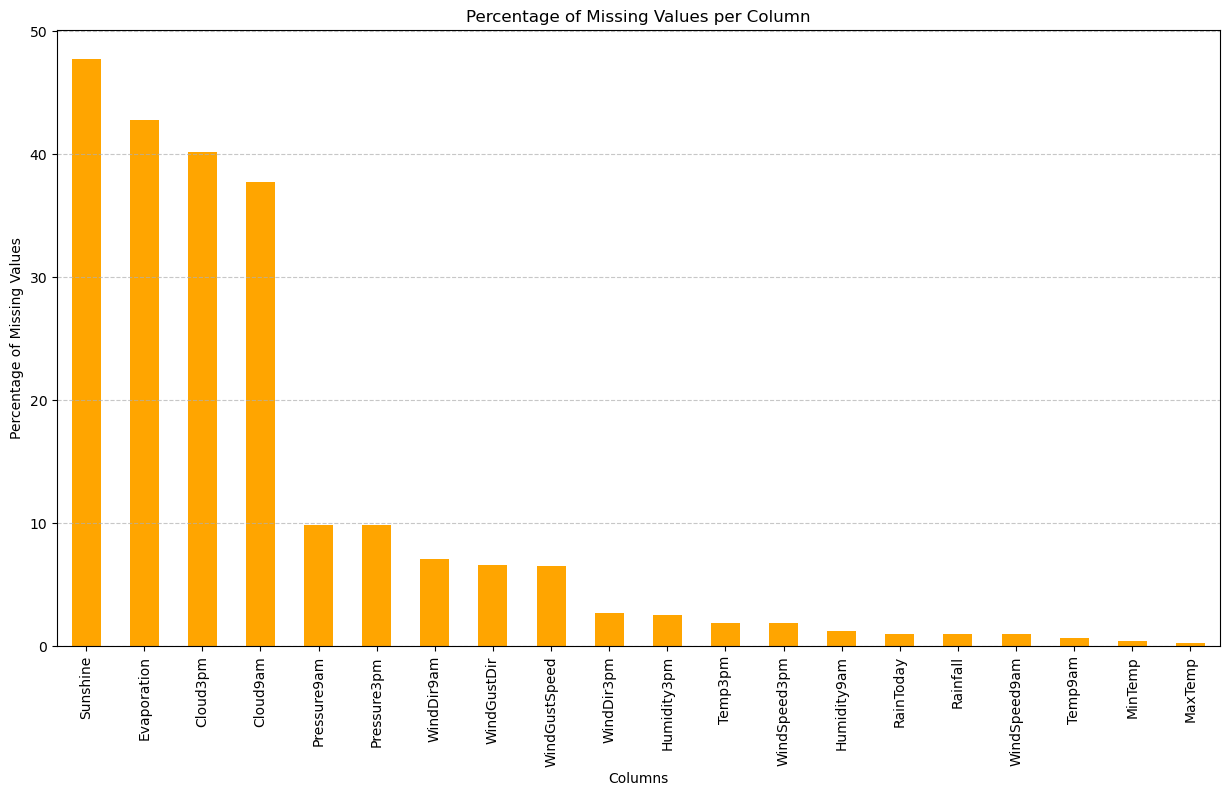

In [18]:
na_percentage = (df.isna().sum() / len(df)) * 100

# Filter out columns with no missing values
na_percentage = na_percentage[na_percentage > 0]

# Sort by the percentage of missing values
na_percentage = na_percentage.sort_values(ascending=False)
print(na_percentage)
# Plot the percentage of missing values
plt.figure(figsize=(15, 8))
na_percentage.plot(kind='bar', color='orange')
plt.title('Percentage of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Analyse univarie


### quantitative


In [ ]:
dtypes = df.dtypes.reset_index()
dtypes.columns = ['column', 'dtype']  #
dtypes['dtype'] = dtypes['dtype'].astype(str)  

print('Df dtypes:')
print(dtypes.groupby('dtype').size())

Df dtypes:
dtype
float64    17
object      7
dtype: int64


In [23]:
def numeric_analysis(df):
        return print(df.describe().T)
numeric_analysis(df)

                  count         mean        std    min     25%     50%  \
MinTemp        141556.0    12.186400   6.403283   -8.5     7.6    12.0   
MaxTemp        141871.0    23.226784   7.117618   -4.8    17.9    22.6   
Rainfall       140787.0     2.349974   8.465173    0.0     0.0     0.0   
Evaporation     81350.0     5.469824   4.188537    0.0     2.6     4.8   
Sunshine        74377.0     7.624853   3.781525    0.0     4.9     8.5   
WindGustSpeed  132923.0    39.984292  13.588801    6.0    31.0    39.0   
WindSpeed9am   140845.0    14.001988   8.893337    0.0     7.0    13.0   
WindSpeed3pm   139563.0    18.637576   8.803345    0.0    13.0    19.0   
Humidity9am    140419.0    68.843810  19.051293    0.0    57.0    70.0   
Humidity3pm    138583.0    51.482606  20.797772    0.0    37.0    52.0   
Pressure9am    128179.0  1017.653758   7.105476  980.5  1012.9  1017.6   
Pressure3pm    128212.0  1015.258204   7.036677  977.1  1010.4  1015.2   
Cloud9am        88536.0     4.437189  

In [25]:
def univariate_analysis(df, base_folder="univariate_analysis"):
        # Ensure the base folder exists
        if not os.path.exists(base_folder):
            os.makedirs(base_folder)
        
        # Select numeric columns
        numeric_cols = df.select_dtypes(include=['number']).columns
        
        for col in numeric_cols:
            # Create a folder for the analysis
            col_folder = os.path.join(base_folder, col)
            if not os.path.exists(col_folder):
                os.makedirs(col_folder)
            
            print(f"\nPerforming Univariate Analysis for: {col}")
            
            # Create a single figure with 2x2 layout
            fig, axes = plt.subplots(2, 2, figsize=(12, 10))
            fig.suptitle(f'Univariate Analysis for {col}', fontsize=16)
            
            # Bar Chart
            sns.barplot(
                x=df[col].value_counts().index, 
                y=df[col].value_counts().values, 
                palette="viridis", 
                ax=axes[0, 0]
            )
            axes[0, 0].set_title('Bar Chart')
            axes[0, 0].set_xlabel(col)
    
            axes[0, 0].set_ylabel('Frequency')
            
            # Box Plot
            sns.boxplot(y=df[col], palette="viridis", ax=axes[0, 1])
            axes[0, 1].set_title('Box Plot')
            axes[0, 1].set_xlabel(col)
            
            # Density Plot
            sns.kdeplot(df[col], fill=True, color="blue", alpha=0.6, ax=axes[1, 0])
            axes[1, 0].set_title('Density Plot')
            axes[1, 0].set_xlabel(col)
            axes[1, 0].set_ylabel('Density')
            
            # Histogram
            sns.histplot(df[col], kde=False, color="green", ax=axes[1, 1])
            axes[1, 1].set_title('Histogram')
            axes[1, 1].set_xlabel(col)
            axes[1, 1].set_ylabel('Frequency')
            
            # Adjust layout
            plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the main title
            
            # Save the combined plot
            combined_plot_path = os.path.join(col_folder, f"{col}_univariate_analysis.png")
            plt.savefig(combined_plot_path, bbox_inches='tight')
            plt.close()
            
            print(f"Combined plots for {col} saved in: {combined_plot_path}")

In [26]:
univariate_analysis(df, base_folder="univariate_analysis")


Performing Univariate Analysis for: MinTemp


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette="viridis", ax=axes[0, 1])


Combined plots for MinTemp saved in: univariate_analysis\MinTemp\MinTemp_univariate_analysis.png

Performing Univariate Analysis for: MaxTemp


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette="viridis", ax=axes[0, 1])


Combined plots for MaxTemp saved in: univariate_analysis\MaxTemp\MaxTemp_univariate_analysis.png

Performing Univariate Analysis for: Rainfall


...

Combined plots for Temp9am saved in: univariate_analysis\Temp9am\Temp9am_univariate_analysis.png

Performing Univariate Analysis for: Temp3pm


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette="viridis", ax=axes[0, 1])


Combined plots for Temp3pm saved in: univariate_analysis\Temp3pm\Temp3pm_univariate_analysis.png

Performing Univariate Analysis for: RISK_MM


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2357958493.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette="viridis", ax=axes[0, 1])


Combined plots for RISK_MM saved in: univariate_analysis\RISK_MM\RISK_MM_univariate_analysis.png


### qualitative

In [28]:
def categorical_analysis(df):
    return print(df.select_dtypes(include='object').describe().T)
categorical_analysis(df)

               count unique         top    freq
Date          142193   3436  2013-12-01      49
Location      142193     49    Canberra    3418
WindGustDir   132863     16           W    9780
WindDir9am    132180     16           N   11393
WindDir3pm    138415     16          SE   10663
RainToday     140787      2          No  109332
RainTomorrow  142193      2          No  110316


In [29]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def univariate_analysis_categorical(df, base_folder="univariate_analysis_categorical"):
    """
    Perform univariate analysis on categorical variables by generating:
    - A count plot (bar chart)
    - A pie chart

    Parameters:
        df (pd.DataFrame): DataFrame to analyze.
        base_folder (str): Folder to save the generated images.
    """
    os.makedirs(base_folder, exist_ok=True)  # Create base folder if not exists

    # Select categorical columns
    # Liste des colonnes à exclure
    exclude_cols = {'id', 'customer_id', 'type_of_loan', 'name', 'ssn'}
    # Sélection des colonnes catégorielles sans celles à exclure
    categorical_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns if col not in exclude_cols]
    for col in categorical_cols:
        print(f"\nPerforming Univariate Analysis for: {col}")

        # Create folder for each variable
        col_folder = os.path.join(base_folder, col)
        os.makedirs(col_folder, exist_ok=True)

        # Drop NaN values for visualization
        col_data = df[col].dropna()

        # Create figure
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f'Univariate Analysis for {col}', fontsize=16)

        # Count Plot (Bar Chart)
        sns.countplot(
            x=col_data, 
            order=col_data.value_counts().index,  # Order by frequency
            palette="viridis", 
            ax=axes[0]
        )
        axes[0].set_title('Count Plot')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')
        plt.xticks(rotation=45)

        # Pie Chart
        explode_values = [0.05] * len(col_data.unique())  # Small separation between slices
        col_data.value_counts().plot.pie(
            autopct='%1.1f%%', 
            colors=sns.color_palette("viridis", len(col_data.unique())),
            explode=explode_values,
            ax=axes[1]
        )
        axes[1].set_title('Pie Chart')
        axes[1].set_ylabel('')  # Remove y-label for better visualization

        # Save the figure
        plot_path = os.path.join(col_folder, f"{col}_univariate_analysis.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()

        print(f"Saved: {plot_path}")

univariate_analysis_categorical(df, base_folder="univariate_analysis_categorical")


Performing Univariate Analysis for: Date


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2370571976.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Saved: univariate_analysis_categorical\Date\Date_univariate_analysis.png

Performing Univariate Analysis for: Location


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2370571976.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Saved: univariate_analysis_categorical\Location\Location_univariate_analysis.png

Performing Univariate Analysis for: WindGustDir


...

Saved: univariate_analysis_categorical\WindDir3pm\WindDir3pm_univariate_analysis.png

Performing Univariate Analysis for: RainToday


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2370571976.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Saved: univariate_analysis_categorical\RainToday\RainToday_univariate_analysis.png

Performing Univariate Analysis for: RainTomorrow


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2370571976.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Saved: univariate_analysis_categorical\RainTomorrow\RainTomorrow_univariate_analysis.png


## multivariaty analysis

In [30]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [31]:
target = 'RainTomorrow'

In [32]:
print(df["RainTomorrow"].value_counts(normalize=True) * 100)

RainTomorrow
No     77.581878
Yes    22.418122
Name: proportion, dtype: float64


In [33]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

def multivariate_analysis(target, df, base_folder="multivariate_analysis", sample_frac=0.2):
    """
    Performs multivariate analysis with respect to the target variable.
    Outputs:
        - Categorical vs Target: Box plots or count plots.
        - Numeric vs Target: Scatter plots with density curves.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to analyze.
        target (str): The target variable for comparison.
        base_folder (str): Directory to save the analysis images.
        sample_frac (float): Fraction of data to sample for faster plotting.
    """
    # Ensure the base folder exists
    os.makedirs(base_folder, exist_ok=True)
    
    # Select categorical and numeric columns
    exclude_cols = {'id', 'customer_id', 'type_of_loan', 'name', 'ssn'}
    categorical_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns if col not in exclude_cols]
    numeric_cols = [col for col in df.select_dtypes(include=['number']).columns if col not in exclude_cols and col != target]
    
    # --- Categorical vs Target ---
    cat_vs_target_folder = os.path.join(base_folder, "categorical_vs_target")
    os.makedirs(cat_vs_target_folder, exist_ok=True)
    
    def plot_categorical_vs_target(col):
        print(f"Analyzing Categorical vs Target: {target} vs {col}")
        
        plt.figure(figsize=(10, 6))
        if pd.api.types.is_numeric_dtype(df[target]):
            sns.boxplot(x=col, y=target, data=df)
            plt.title(f"{target} Distribution by {col}")
        else:
            sns.countplot(x=col, hue=target, data=df)
            plt.title(f"Count of {col} by {target}")
        plt.xlabel(col)
        plt.ylabel(target if pd.api.types.is_numeric_dtype(df[target]) else "Count")
        
        plot_path = os.path.join(cat_vs_target_folder, f"{target}_vs_{col}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()
        print(f"Saved: {plot_path}")
    
    # Parallelize the plotting for categorical vs target
    with ThreadPoolExecutor() as executor:
        executor.map(plot_categorical_vs_target, categorical_cols)
    
    # --- Numeric vs Target ---
    num_vs_target_folder = os.path.join(base_folder, "numeric_vs_target")
    os.makedirs(num_vs_target_folder, exist_ok=True)
    
    # Sample the data for faster plotting
    sampled_df = df.sample(frac=sample_frac, random_state=42)
    
    def plot_numeric_vs_target(col):
        print(f"Analyzing Numeric vs Target: {target} vs {col}")
        
        plt.figure(figsize=(10, 6))
        if pd.api.types.is_numeric_dtype(df[target]):
            sns.scatterplot(x=target, y=col, data=sampled_df, alpha=0.4, color='purple')
            sns.kdeplot(x=target, y=col, data=sampled_df, color="red", levels=3, linewidths=1)
            plt.title(f"{target} vs {col} (Scatter + Density)")
        else:
            sns.boxplot(x=target, y=col, data=sampled_df)
            plt.title(f"{col} Distribution by {target}")
        plt.xlabel(target)
        plt.ylabel(col)
        
        plot_path = os.path.join(num_vs_target_folder, f"{target}_vs_{col}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()
        print(f"Saved: {plot_path}")
    
    # Parallelize the plotting for numeric vs target
    with ThreadPoolExecutor() as executor:
        executor.map(plot_numeric_vs_target, numeric_cols)
    
    print("\n Multivariate Analysis Completed Successfully!")

In [34]:
multivariate_analysis(target, df, base_folder="multivariate_analysis", sample_frac=0.2)

Analyzing Categorical vs Target: RainTomorrow vs Date
Analyzing Categorical vs Target: RainTomorrow vs Location
Analyzing Categorical vs Target: RainTomorrow vs WindGustDir
Analyzing Categorical vs Target: RainTomorrow vs WindDir9am
Analyzing Categorical vs Target: RainTomorrow vs WindDir3pm
Analyzing Categorical vs Target: RainTomorrow vs RainToday
Analyzing Categorical vs Target: RainTomorrow vs RainTomorrow


C:\Users\HP\AppData\Local\Temp\ipykernel_4260\2608839725.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_path, bbox_inches='tight')


Saved: multivariate_analysis\categorical_vs_target\RainTomorrow_vs_RainTomorrow.png
Saved: multivariate_analysis\categorical_vs_target\RainTomorrow_vs_WindGustDir.png
Saved: multivariate_analysis\categorical_vs_target\RainTomorrow_vs_WindDir3pm.png
Saved: multivariate_analysis\categorical_vs_target\RainTomorrow_vs_WindDir9am.png
Saved: multivariate_analysis\categorical_vs_target\RainTomorrow_vs_Location.png
Saved: multivariate_analysis\categorical_vs_target\RainTomorrow_vs_Date.png
Saved: multivariate_analysis\categorical_vs_target\RainTomorrow_vs_RainToday.png
Analyzing Numeric vs Target: RainTomorrow vs MinTemp
Analyzing Numeric vs Target: RainTomorrow vs MaxTemp
Analyzing Numeric vs Target: RainTomorrow vs Rainfall
Analyzing Numeric vs Target: RainTomorrow vs Evaporation
Analyzing Numeric vs Target: RainTomorrow vs Sunshine
Analyzing Numeric vs Target: RainTomorrow vs WindGustSpeed
Analyzing Numeric vs Target: RainTomorrow vs WindSpeed9am
Analyzing Numeric vs Target: RainTomorrow vs

## advanced analysis 

In [37]:
def scatter_plot_combinations_categorical_target(target, df, base_folder="scatter_combinations_cat_target"):
    """
    Generates scatter plots for all combinations of two numerical variables,
    colored by a categorical target variable.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to analyze.
        target (str): The categorical target variable.
        base_folder (str): Directory to save the scatter plots.
    """
    import os
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    # Check that target is categorical
    if np.issubdtype(df[target].dtype, np.number):
        print(f"❌ Skipping: Target '{target}' is numeric. This version is for categorical targets only.")
        return

    # Ensure the base folder exists
    os.makedirs(base_folder, exist_ok=True)

    # Optional: sample the data to avoid oversize
    if df.shape[0] > 5000:
        df = df.sample(n=5000, random_state=42)
        print("ℹ️ Sampled 5000 rows to avoid oversized plots.")

    # Numerical columns (excluding target)
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    # Generate all combinations of two numeric variables
    from itertools import combinations
    combos = list(combinations(numeric_cols, 2))

    for x_col, y_col in combos:
        print(f"📊 Plotting: {x_col} vs {y_col} colored by {target}")

        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            x=x_col,
            y=y_col,
            hue=target,
            data=df,
            palette="viridis",
            alpha=0.6
        )
        plt.title(f'{y_col} vs {x_col} colored by {target}')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()

        # Save plot
        folder_name = os.path.join(base_folder, f"{y_col}_vs_{x_col}_by_{target}")
        os.makedirs(folder_name, exist_ok=True)
        file_path = os.path.join(folder_name, f"{y_col}_vs_{x_col}_by_{target}.png")
        plt.savefig(file_path, bbox_inches='tight')
        plt.close()
        print(f"✅ Saved to: {file_path}")
scatter_plot_combinations_categorical_target("RainTomorrow", df)


ℹ️ Sampled 5000 rows to avoid oversized plots.
📊 Plotting: MinTemp vs MaxTemp colored by RainTomorrow
✅ Saved to: scatter_combinations_cat_target\MaxTemp_vs_MinTemp_by_RainTomorrow\MaxTemp_vs_MinTemp_by_RainTomorrow.png
📊 Plotting: MinTemp vs Rainfall colored by RainTomorrow
✅ Saved to: scatter_combinations_cat_target\Rainfall_vs_MinTemp_by_RainTomorrow\Rainfall_vs_MinTemp_by_RainTomorrow.png
📊 Plotting: MinTemp vs Evaporation colored by RainTomorrow
✅ Saved to: scatter_combinations_cat_target\Evaporation_vs_MinTemp_by_RainTomorrow\Evaporation_vs_MinTemp_by_RainTomorrow.png
📊 Plotting: MinTemp vs Sunshine colored by RainTomorrow
✅ Saved to: scatter_combinations_cat_target\Sunshine_vs_MinTemp_by_RainTomorrow\Sunshine_vs_MinTemp_by_RainTomorrow.png
📊 Plotting: MinTemp vs WindGustSpeed colored by RainTomorrow
✅ Saved to: scatter_combinations_cat_target\WindGustSpeed_vs_MinTemp_by_RainTomorrow\WindGustSpeed_vs_MinTemp_by_RainTomorrow.png
📊 Plotting: MinTemp vs WindSpeed9am colored by RainT

## correlation matrix


In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Supprimer les lignes contenant des NaN ou des inf
column_headers = df.columns.to_list()
quantitative_columns = [col for col in column_headers if df[col].dtype in ['int64', 'float64']]

# Nettoyage des valeurs infinies et manquantes
cleaned_df = df[quantitative_columns].replace([np.inf, -np.inf], np.nan).dropna()

# Vérifier si les valeurs infinies ou NaN ont disparu
print(cleaned_df.isna().sum())  # Devrait afficher 0 partout

def correlation_and_significance(numeric_df, base_folder="correlation_analysis"):
    """
    Generates a correlation matrix heatmap with significance markers.
    
    Parameters:
        numeric_df (pd.DataFrame): The cleaned DataFrame with numerical variables.
        base_folder (str): Directory to save the analysis images."""
    # Assurer l'existence du dossier de sauvegarde
    if not os.path.exists(base_folder):
        os.makedirs(base_folder)
    
    cols = numeric_df.columns
    
    # Calculer la matrice de corrélation
    corr_matrix = numeric_df.corr()
    
    # Initialiser la matrice des p-values
    p_values = pd.DataFrame(np.ones((len(cols), len(cols))), columns=cols, index=cols)
    
    # Calculer les p-values pour chaque paire de variables
    for row in cols:
        for col in cols:
            if row != col:
                _, p_value = pearsonr(numeric_df[row], numeric_df[col])
                p_values.loc[row, col] = p_value
    
    # --- Affichage de la matrice de corrélation avec significativité ---
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

    # Ajouter des marqueurs de significativité
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i != j:  # Ne pas marquer la diagonale
                p_val = p_values.iloc[i, j]
                x = j + 0.5
                y = i + 0.5
                
                # Vert si significatif (p < 0.05), rouge sinon
                color = 'green' if p_val < 0.05 else 'red'
                plt.plot(x, y, 'o', color=color)
    
    plt.title('Correlation Matrix with Significance (Numerical Variables)', fontsize=18)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Sauvegarde de l'image
    corr_plot_path = os.path.join(base_folder, "correlation_matrix_significance.png")
    plt.savefig(corr_plot_path, bbox_inches='tight')
    plt.close()
    
    print(f"Correlation matrix with significance saved in: {corr_plot_path}")

# Exécuter la fonction avec les données nettoyées
correlation_and_significance(cleaned_df, base_folder="correlation_analysis")


KeyboardInterrupt



## cleaning data

### data issues

In [40]:
import pandas as pd
import numpy as np

class WeatherCleaner:
    def __init__(self, df):
        self.df = df.copy()

    def clean(self):
        df = self.df

        # Convert Date
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

        # Température logique
        df.loc[df['MinTemp'] > df['MaxTemp'], ['MinTemp', 'MaxTemp']] = np.nan
        df = df[(df['MinTemp'] >= -10) & (df['MaxTemp'] <= 50)]

        # Humidité entre 0 et 100
        df.loc[(df['Humidity9am'] < 0) | (df['Humidity9am'] > 100), 'Humidity9am'] = np.nan
        df.loc[(df['Humidity3pm'] < 0) | (df['Humidity3pm'] > 100), 'Humidity3pm'] = np.nan

        # Pression entre 980 et 1050 hPa
        df.loc[(df['Pressure9am'] < 980) | (df['Pressure9am'] > 1050), 'Pressure9am'] = np.nan
        df.loc[(df['Pressure3pm'] < 980) | (df['Pressure3pm'] > 1050), 'Pressure3pm'] = np.nan

        # Vitesse du vent (positives, pas trop extrêmes)
        wind_cols = ['WindSpeed9am', 'WindSpeed3pm', 'WindGustSpeed']
        for col in wind_cols:
            df.loc[(df[col] < 0) | (df[col] > 150), col] = np.nan

        # Cloud cover (0 à 8)
        df.loc[(df['Cloud9am'] < 0) | (df['Cloud9am'] > 8), 'Cloud9am'] = np.nan
        df.loc[(df['Cloud3pm'] < 0) | (df['Cloud3pm'] > 8), 'Cloud3pm'] = np.nan

        # Évaporation, pluie, risque
        for col in ['Rainfall', 'Evaporation', 'RISK_MM']:
            df.loc[df[col] < 0, col] = np.nan

        # Températures horaires entre min et max
        df.loc[(df['Temp9am'] < df['MinTemp']) | (df['Temp9am'] > df['MaxTemp']), 'Temp9am'] = np.nan
        df.loc[(df['Temp3pm'] < df['MinTemp']) | (df['Temp3pm'] > df['MaxTemp']), 'Temp3pm'] = np.nan

        self.df = df.reset_index(drop=True)
        return self.df

    def summary(self):
        print("✅ Data cleaned. Here's an overview:")
        print(self.df.info())
        print("\nMissing values per column:\n")
        print(self.df.isnull().sum().sort_values(ascending=False))


In [41]:
# Exemple : nettoyage de ton DataFrame météo
cleaner = WeatherCleaner(df)
clean_df = cleaner.clean()
cleaner.summary()


✅ Data cleaned. Here's an overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141322 entries, 0 to 141321
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           141322 non-null  datetime64[ns]
 1   Location       141322 non-null  object        
 2   MinTemp        141322 non-null  float64       
 3   MaxTemp        141322 non-null  float64       
 4   Rainfall       140086 non-null  float64       
 5   Evaporation    81181 non-null   float64       
 6   Sunshine       74241 non-null   float64       
 7   WindGustDir    132600 non-null  object        
 8   WindGustSpeed  132658 non-null  float64       
 9   WindDir9am     131759 non-null  object        
 10  WindDir3pm     137936 non-null  object        
 11  WindSpeed9am   140296 non-null  float64       
 12  WindSpeed3pm   139044 non-null  float64       
 13  Humidity9am    139921 non-null  float64       
 14  Humidity3pm    1

### missing values

In [42]:
df.isna().sum() 

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

In [45]:
class MissingDataHandler:
    def __init__(self, df):
        self.df = df  # Appliquer les changements directement sur le DataFrame original
    # 1. Supprimer les colonnes avec trop de valeurs manquantes
    def drop_column(self, threshold=0.5):
        """Drop columns with more than threshold% missing values."""
        self.df.dropna(thresh=len(self.df) * (1 - threshold), axis=1, inplace=True)
    # 2. Supprimer les lignes avec des valeurs manquantes
    def drop_row(self):
        """Drop rows with any missing values."""
        self.df.dropna(inplace=True)
    # 3. Imputation avec la moyenne ou la médiane
    def impute_mean_median(self, strategy='mean'):
        """Impute missing values in all numerical columns with mean or median."""
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        for col in num_cols:
            imputer = SimpleImputer(strategy=strategy)
            self.df[col] = imputer.fit_transform(self.df[[col]])
    
    def group_imputation(self, group_by, strategy='mean'):
        """Group-wise imputation using mean or median for all numerical columns."""
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        for col in num_cols:
            self.df[col].fillna(self.df.groupby(group_by)[col].transform(strategy), inplace=True)
    # 4. Remplir par la valeur la plus fréquente (catégories)
    def impute_categorical(self, strategy='most_frequent', fill_value=None):
        """Impute missing values in all categorical columns."""
        cat_cols = self.df.select_dtypes(exclude=[np.number]).columns
        for col in cat_cols:
            if strategy == 'constant' and fill_value is not None:
                self.df[col].fillna(fill_value, inplace=True)
            else:
                imputer = SimpleImputer(strategy=strategy) 
                self.df[col] = imputer.fit_transform(self.df[[col]]).ravel()
    # 5. Remplissage en avant et en arrière
    def forward_fill(self):
        """Forward fill missing values for all columns."""
        self.df.fillna(method='ffill', inplace=True)
    
    def backward_fill(self):
        """Backward fill missing values for all columns."""
        self.df.fillna(method='bfill', inplace=True)
    # 6. Interpolation (utile pour les séries temporelles)
    def interpolate(self, method='linear'):
        """Interpolate missing values for all numerical columns."""
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        for col in num_cols:
            self.df[col].interpolate(method=method, inplace=True)
    # using KNN for all numerical columns
    def knn_imputation(self, n_neighbors=5):
        """Impute missing values using KNN for all numerical columns."""
        imputer = KNNImputer(n_neighbors=n_neighbors)
        self.df[:] = imputer.fit_transform(self.df)
    # using Iterative Imputer (MICE)
    def iterative_imputation(self):
        """Impute missing values using Iterative Imputer (MICE) for all numerical columns."""
        imputer = IterativeImputer()
        self.df[:] = imputer.fit_transform(self.df)
    
    def get_dataframe(self):
        """Return the processed DataFrame."""
        return self.df

In [46]:
# Importer la classe
handler = MissingDataHandler(df)
# Supprimer les colonnes avec plus de 50% de valeurs manquantes
handler.drop_column(threshold=0.9)
# Imputation des valeurs manquantes
handler.impute_mean_median(strategy='median')  # Impute par la moyenne pour les colonnes numériques
handler.impute_categorical(strategy='most_frequent')  # Impute par la valeur la plus fréquente pour les catégoriques
# Utiliser forward fill ou backward fill si nécessaire
handler.forward_fill()
# Récupérer le DataFrame traité
cleaned_df = handler.get_dataframe()
print("\nDataFrame après traitement :")
cleaned_df.info()
df=cleaned_df
df.describe()


DataFrame après traitement :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   Evaporation    142193 non-null  float64
 6   Sunshine       142193 non-null  float64
 7   WindGustDir    142193 non-null  object 
 8   WindGustSpeed  142193 non-null  float64
 9   WindDir9am     142193 non-null  object 
 10  WindDir3pm     142193 non-null  object 
 11  WindSpeed9am   142193 non-null  float64
 12  WindSpeed3pm   142193 non-null  float64
 13  Humidity9am    142193 non-null  float64
 14  Humidity3pm    142193 non-null  float64
 15  Pressure9am    142193 non-null  float64
 16  Pressure3pm    142193 non-null  float64
 17 

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000
mean,12.185565,23.225365,2.326738,5.183213,8.042236,39.920123,13.992489,18.644279,68.858235,51.495742,1017.648460,1015.252481,4.649568,4.702658,16.985681,21.675977,2.360682
std,6.388936,7.109617,8.426426,3.185401,2.769638,13.140632,8.851614,8.721688,18.932512,20.532227,6.746267,6.681810,2.294357,2.118753,6.472206,6.871243,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,4.000000,8.200000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.000000,3.000000,4.000000,12.300000,16.700000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.600000,5.400000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.300000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


### removing dupliced values

In [47]:
def remove_duplicates(df, subset=None, keep='first', inplace=False):
    """
    Removes duplicate rows from the DataFrame and provides a summary of duplicates.
    Parameters:
        df (pd.DataFrame): The DataFrame from which to remove duplicates.
        subset (list): List of columns to consider for duplicate checking. 
                    If None, checks all columns.
        keep (str): Which duplicates to keep. Options:
            - 'first': Keep the first occurrence (default).
            - 'last': Keep the last occurrence.
            - 'none': Drop all duplicates.
        inplace (bool): If True, modifies the original DataFrame. 
                        If False, returns a new DataFrame.
    Returns:
        pd.DataFrame: DataFrame with duplicates removed (if inplace=False).
    """
    if keep not in ['first', 'last', 'none']:
        raise ValueError("keep must be one of 'first', 'last', or 'none'.")
    # Count duplicates before removal
    total_rows = len(df)
    duplicate_rows = df.duplicated(subset=subset, keep=False).sum()
    percentage_duplicates = (duplicate_rows / total_rows) * 100
    print(f"Total Rows: {total_rows}")
    print(f"Duplicate Rows: {duplicate_rows} ({percentage_duplicates:.2f}%)")
    if duplicate_rows == 0:
        print("No duplicates found. No rows removed.")
        return df if not inplace else None
     # Handle duplicate removal    if keep == 'none':
        # Drop all duplicates and keep only unique rows
        duplicated_mask = df.duplicated(subset=subset, keep=False)
        result = df[~duplicated_mask]
    else:
        # Use pandas built-in drop_duplicates
        result = df.drop_duplicates(subset=subset, keep=keep)
    # Count duplicates after removal
    remaining_rows = len(result)
    rows_removed = total_rows - remaining_rows
    print(f"Rows Removed: {rows_removed}")
    print(f"Remaining Rows: {remaining_rows}")
    if rows_removed > 0:
        print("Duplicates successfully removed.")
    else:
        print("No duplicates were removed.")
    if inplace:
        df.drop_duplicates(subset=subset, keep=keep, inplace=True)
    else:
        return result
remove_duplicates(df, subset=None, keep='first', inplace=False)

Total Rows: 142193
Duplicate Rows: 0 (0.00%)
No duplicates found. No rows removed.


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,W,...,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,NNW,...,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,W,...,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,SE,...,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Uluru,3.5,21.8,0.0,4.8,8.5,E,31.0,ESE,...,27.0,1024.7,1021.2,5.0,5.0,9.4,20.9,No,0.0,No
142189,2017-06-21,Uluru,2.8,23.4,0.0,4.8,8.5,E,31.0,SE,...,24.0,1024.6,1020.3,5.0,5.0,10.1,22.4,No,0.0,No
142190,2017-06-22,Uluru,3.6,25.3,0.0,4.8,8.5,NNW,22.0,SE,...,21.0,1023.5,1019.1,5.0,5.0,10.9,24.5,No,0.0,No
142191,2017-06-23,Uluru,5.4,26.9,0.0,4.8,8.5,N,37.0,SE,...,24.0,1021.0,1016.8,5.0,5.0,12.5,26.1,No,0.0,No


### outliers

In [48]:
class DataCleaner:
    def __init__(self, df):
        """
        Initializes the class with a DataFrame.
        
        Parameters:
            df (pd.DataFrame): The dataset to be cleaned.
        """
        self.df = df
        self.numeric_columns = self.df.select_dtypes(include=['number']).columns.to_list()

    def remove_na_inf(self):
        """Replaces infinite values with NaN and drops rows containing NaN."""
        self.df[self.numeric_columns] = self.df[self.numeric_columns].replace([np.inf, -np.inf], np.nan).dropna()
        print(" NaN and infinite values removed.")

    def detect_outliers_iqr(self):
        """
        Detects outliers using the Interquartile Range (IQR) method.
        
        Returns:
            A dictionary containing outlier indices for each column.
        """
        outliers_dict = {}

        for col in self.numeric_columns:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Find outlier indices
            outliers = self.df[(self.df[col] < lower_bound) | (self.df[col] > upper_bound)].index
            outliers_dict[col] = outliers

        return outliers_dict

    def drop_outliers(self):
        """Drops rows containing outliers based on the IQR method."""
        outliers_dict = self.detect_outliers_iqr()
        outlier_indices = set(index for indices in outliers_dict.values() for index in indices)
        self.df = self.df.drop(outlier_indices)
        print(" Outliers removed.")

    def replace_outliers_iqr(self):
        """Replaces outliers with the lower and upper IQR bounds (Winsorization)."""
        for col in self.numeric_columns:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            self.df[col] = np.where(self.df[col] < lower_bound, lower_bound, self.df[col])
            self.df[col] = np.where(self.df[col] > upper_bound, upper_bound, self.df[col])
        
        print(" Outliers replaced using IQR bounds.")

    def replace_outliers_median(self):
        """Replaces outliers with the column median."""
        for col in self.numeric_columns:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            median_value = self.df[col].median()

            self.df[col] = np.where((self.df[col] < lower_bound) | (self.df[col] > upper_bound), median_value, self.df[col])
        
        print(" Outliers replaced with median.")

    def replace_outliers_knn(self, n_neighbors=5):
        """Replaces outliers using K-Nearest Neighbors (KNN) imputation."""
        imputer = KNNImputer(n_neighbors=n_neighbors)
        self.df[self.numeric_columns] = imputer.fit_transform(self.df[self.numeric_columns])
        print(" Outliers replaced using KNN imputation.")

    def save_cleaned_data(self, filename="cleaned_data.csv"):
        """Saves the cleaned DataFrame as a CSV file."""
        self.df.to_csv(filename, index=False)
        print(f" Cleaned data saved to {filename}.")

    def clean_data(self, method="median"):
        """
        Cleans missing values and applies an outlier handling method.

        Parameters:
            method (str): The method to handle outliers ('drop', 'winsorization', 'median', 'knn').
        """
        self.remove_na_inf()  # Remove NaN and infinite values

        if method == "drop":
            self.drop_outliers()
        elif method == "winsorization":
            self.replace_outliers_iqr()
        elif method == "median":
            self.replace_outliers_median()
        elif method == "knn":
            self.replace_outliers_knn()
        else:
            print("Invalid method. Choose from 'drop', 'winsorization', 'median', 'knn'.")

        self.save_cleaned_data()

In [49]:
# Initialisation du DataCleaner
cleaner = DataCleaner(df)
# Nettoyage des données avec la méthode choisie
cleaner.clean_data(method="median")

 NaN and infinite values removed.
 Outliers replaced with median.
 Cleaned data saved to cleaned_data.csv.


### Data type conversions

In [50]:
class DataTypeConverter:
    def __init__(self, df):
        """
        Initializes the class with a DataFrame.
        
        Parameters:
            df (pd.DataFrame): The dataset to be converted.
        """
        self.df = df 

    def convert_data_types(self):
        """
        Converts column data types based on their values:
        - Converts strings containing numbers to int/float.
        - Converts float columns with only integer values to int.
        - Converts boolean-like columns (0/1) to bool.
        - Converts date-like columns to datetime.
        - Converts categorical columns (few unique values) to category.
        """
        for col in self.df.columns:
            # Convert numeric strings to proper numbers
            if self.df[col].dtype == 'object':
                try:
                    self.df[col] = pd.to_numeric(self.df[col])
                except ValueError:
                    pass  # Keep as object if conversion fails

            # Convert float columns with only integer values to int
            if self.df[col].dtype == 'float64':
                if (self.df[col].dropna() % 1 == 0).all():
                    self.df[col] = self.df[col].astype(int)

            # Convert boolean-like columns (0/1) to bool
            if set(self.df[col].dropna().unique()) == {0, 1}:
                self.df[col] = self.df[col].astype(bool)

            # Convert date-like columns to datetime
            if self.df[col].dtype == 'object':
                try:
                    self.df[col] = pd.to_datetime(self.df[col])
                except ValueError:
                    pass  # Keep as object if not a valid date format
            
            # Convert categorical columns (few unique values) to category
            if self.df[col].dtype == 'object' and self.df[col].nunique() / len(self.df) < 0.05:
                self.df[col] = self.df[col].astype('category')

        print(" Data types converted successfully.")

    def get_dataframe(self):
        """Returns the converted DataFrame."""
        return self.df

## feature eng

## models

## linear regression

## logistic regression